Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
df = pd.read_csv('/content/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Basic Understanding

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Select Important Features

In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

Find Optimal Clusters (Elbow Method)





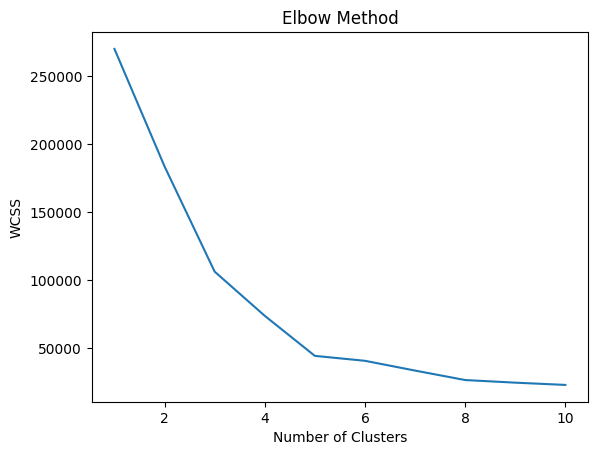

In [5]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

Apply K-Means

In [6]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

df['Cluster'] = y_kmeans

Visualize Clusters

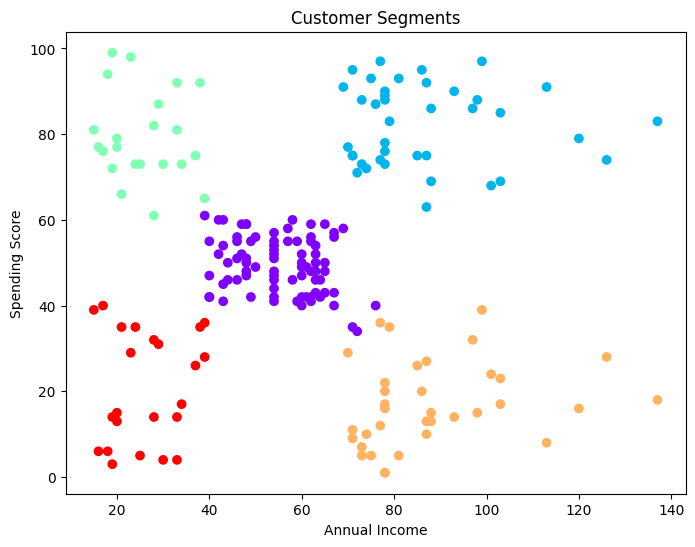

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_kmeans, cmap='rainbow')

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')

plt.show()

Cluster Centers

In [8]:
kmeans.cluster_centers_

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

### Predict Cluster for New Data

In [11]:
new_data_cluster_1 = np.array([[85, 80]]) # Example: Annual Income = 85, Spending Score = 80 (close to Cluster 1 center)
new_data_cluster_1_df = pd.DataFrame(new_data_cluster_1, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
predicted_cluster_1 = kmeans.predict(new_data_cluster_1_df)
print(f"The new data point (Annual Income: {new_data_cluster_1[0,0]}, Spending Score: {new_data_cluster_1[0,1]}) belongs to Cluster: {predicted_cluster_1[0]}")

The new data point (Annual Income: 85, Spending Score: 80) belongs to Cluster: 1


### Customer Segmentation Insights

1. Customers are divided into 5 groups based on spending behavior.
2. High income + high spending → Target customers.
3. High income + low spending → Potential customers.
4. Low income + high spending → Risky segment.
5. Low income + low spending → Least priority group.